# 02-Semantic Similarity & Cross-Encoders

In Lesson 01, we discovered the fatal flaw of Lexical Metrics (BLEU and ROUGE). Because they rely on exact physical character overlap, they score a 0% when a generative model outputs a perfectly accurate paraphrase using synonyms.

To evaluate modern LLMs, our metrology engines must understand semantics—the mathematical "meaning" of language. We achieve this by projecting unstructured text into continuous, high-dimensional vector spaces.

In this module, we will engineer three distinct semantic evaluation architectures: **Bi-Encoders** (for fast cosine similarity), **BERTScore** (for token-level greedy matching), and **Cross-Encoders** (for mathematically rigorous, full self-attention grading). We will execute all of this locally on your workstation's CPU/GPU for exactly $0.00.

# 1. The Mathematics of High-Dimensional Semantics

### The Bi-Encoder (Sentence Transformers)

A Bi-Encoder utilizes a transformer network (like BERT) to map an entire sentence $S$ into a single, dense vector representation $\mathbf{v} \in \mathbb{R}^d$ (where $d$ is typically 384 or 768 dimensions).


$$f_{\text{enc}}(S_1) = \mathbf{u}, \quad f_{\text{enc}}(S_2) = \mathbf{v}$$

To calculate semantic equivalence, we compute the **Cosine Similarity**, which measures the cosine of the angle $\theta$ between the two vectors. If the sentences mean the exact same thing, their vectors point in the exact same direction ($\cos(0^\circ) = 1.0$):


$$\text{Similarity}(S_1, S_2) = \cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{\Vert{}\mathbf{u}\Vert{}_2 \Vert{}\mathbf{v}\Vert{}_2} = \frac{\sum_{i=1}^d u_i v_i}{\sqrt{\sum_{i=1}^d u_i^2} \sqrt{\sum_{i=1}^d v_i^2}}$$


Bi-Encoders are incredibly fast because vectors can be pre-computed and stored in databases (like FAISS or Pinecone), allowing for $O(1)$ comparisons.

### BERTScore (Token-Level Geometric Matching)

Mapping an entire paragraph to a single vector can compress and destroy fine-grained details. **BERTScore** solves this by extracting the contextual embeddings for *every single token* (word piece) in the Reference ($R$) and the Candidate ($C$).
It calculates a pairwise cosine similarity matrix between every token vector $\mathbf{r}_i$ and $\mathbf{c}_j$. It then computes Recall by greedily matching each reference token to its closest candidate token:


$$R_{\text{BERT}} = \frac{1}{\vert{}R\vert{}} \sum_{\mathbf{r}_i \in R} \max_{\mathbf{c}_j \in C} \left( \mathbf{r}_i^\top \mathbf{c}_j \right)$$


*(Precision is calculated symmetrically by reversing the max operator).*

### The Cross-Encoder (Full Self-Attention)

Bi-Encoders suffer from "blindness"—the vector $\mathbf{u}$ is generated completely unaware of $\mathbf{v}$.
A **Cross-Encoder** concatenates the Reference and Candidate into a single sequence separated by a special token: `[CLS] Reference [SEP] Candidate [SEP]`.
This string is passed through the Transformer layers *together*. The self-attention mechanism computes the relationships between every word in the Reference against every word in the Candidate simultaneously ($O(N^2)$ attention bottleneck), finally projecting a single scalar score:


$$f_{\text{cross}}(S_1, S_2) \to [0, 1]$$


Cross-Encoders are significantly slower, but they are the most mathematically accurate open-source evaluators available.

# 2. Imperative Execution: Bi-Encoders & BERTScore

Let's use Python to load localized transformer models. We will re-evaluate the exact same sentences from Lesson 01 that broke our BLEU metric.

In [3]:
# Required installations: pip install sentence-transformers bert-score torch numpy
from sentence_transformers import SentenceTransformer, util
from bert_score import score
import numpy as np
import time

print("--- 🚀 Initializing Semantic Evaluation Sandbox ---")

# The exact sentences that broke our Lexical Metrics in Lesson 01
reference = "Data engineering is the foundation of machine learning."
prediction_exact = "Data engineering is the foundation of machine learning."
prediction_paraphrase = "Data infrastructure forms the basis of artificial intelligence." # BLEU scored this 0.15

print("\n--- 🧮 Lab 1: Bi-Encoder Cosine Similarity ---")
# 1. Load a lightweight, extremely fast Sentence Transformer model into local memory
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Project text strings into high-dimensional space (R^384)
ref_vec = bi_encoder.encode(reference, convert_to_tensor=True)
pred_exact_vec = bi_encoder.encode(prediction_exact, convert_to_tensor=True)
pred_para_vec = bi_encoder.encode(prediction_paraphrase, convert_to_tensor=True)

# 3. Calculate Cosine Similarity
sim_exact = util.cos_sim(ref_vec, pred_exact_vec).item()
sim_para = util.cos_sim(ref_vec, pred_para_vec).item()

print(f"   [Bi-Encoder] Exact Match Score:   {sim_exact:.4f}")
print(f"   [Bi-Encoder] Paraphrase Score:    {sim_para:.4f}")
print("   -> Insight: The Bi-Encoder mathematically understands that 'infrastructure' is a spatial neighbor of 'engineering'.")


print("\n--- 🧬 Lab 2: BERTScore (Token-Level Matching) ---")
# Calculate BERTScore (Precision, Recall, F1)
# lang="en" automatically selects a RoBERTa base model for evaluation
P, R, F1 = score([prediction_paraphrase], [reference], lang="en", verbose=False)

print(f"   [BERTScore] Precision: {P.item():.4f}")
print(f"   [BERTScore] Recall:    {R.item():.4f}")
print(f"   [BERTScore] F1 Score:  {F1.item():.4f}")


--- 🚀 Initializing Semantic Evaluation Sandbox ---

--- 🧮 Lab 1: Bi-Encoder Cosine Similarity ---


README.md: 0.00B [00:00, ?B/s]

   [Bi-Encoder] Exact Match Score:   1.0000
   [Bi-Encoder] Paraphrase Score:    0.5858
   -> Insight: The Bi-Encoder mathematically understands that 'infrastructure' is a spatial neighbor of 'engineering'.

--- 🧬 Lab 2: BERTScore (Token-Level Matching) ---


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   [BERTScore] Precision: 0.9376
   [BERTScore] Recall:    0.9411
   [BERTScore] F1 Score:  0.9394


# 3. Declarative Execution: The Cross-Encoder Evaluator

When evaluating model hallucinations or logical contradictions, Bi-Encoders often fail because they focus on topical similarity (e.g., "The cat sat on the mat" and "The mat sat on the cat" have nearly identical Bi-Encoder embeddings).

To enforce strict logical grading, we invoke the Cross-Encoder.

In [4]:
from sentence_transformers import CrossEncoder

print("\n--- ⚡ Lab 3: Cross-Encoder (Full Self-Attention Evaluation) ---")

# Load a model specifically trained on NLI (Natural Language Inference)
# This model outputs probability logits for [Contradiction, Entailment, Neutral]
cross_encoder = CrossEncoder('cross-encoder/nli-deberta-v3-small')

# Test Case: Logical Contradiction (Bi-Encoders fail this)
nli_ref = "The API server is currently online and accepting traffic."
nli_pred_1 = "The API server is up and running." # Entailment
nli_pred_2 = "The API server is offline and dropping traffic." # Contradiction

# The Cross Encoder expects a list of pairs: [[Ref, Pred1], [Ref, Pred2]]
pairs = [
    [nli_ref, nli_pred_1],
    [nli_ref, nli_pred_2]
]

print("   [API CALL] Executing $O(N^2)$ Self-Attention matrix multiplication...")
start_time = time.perf_counter()
scores = cross_encoder.predict(pairs)
exec_time = (time.perf_counter() - start_time) * 1000

# The model outputs raw logits for [Contradiction, Entailment, Neutral]
# We extract the 'Entailment' (index 1) logic path
entailment_score_1 = scores[0][1]
entailment_score_2 = scores[1][1]

print(f"   ✅ Cross-Encoder Execution Complete in {exec_time:.2f} ms.")
print(f"   [Cross-Encoder] Prediction 1 (Synonym):       {entailment_score_1:.2f} (High Entailment)")
print(f"   [Cross-Encoder] Prediction 2 (Contradiction): {entailment_score_2:.2f} (Fatal Penalty)")


--- ⚡ Lab 3: Cross-Encoder (Full Self-Attention Evaluation) ---


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

   [API CALL] Executing $O(N^2)$ Self-Attention matrix multiplication...
   ✅ Cross-Encoder Execution Complete in 5829.02 ms.
   [Cross-Encoder] Prediction 1 (Synonym):       4.47 (High Entailment)
   [Cross-Encoder] Prediction 2 (Contradiction): -4.05 (Fatal Penalty)


# 4. Visualizing BERTScore Token Alignment & Semantic Physics

To mathematically understand how BERTScore bypasses the exact-match flaw of BLEU, let's visualize the pairwise Token Similarity Matrix $M_{ij}$ that the algorithm computes in the background.

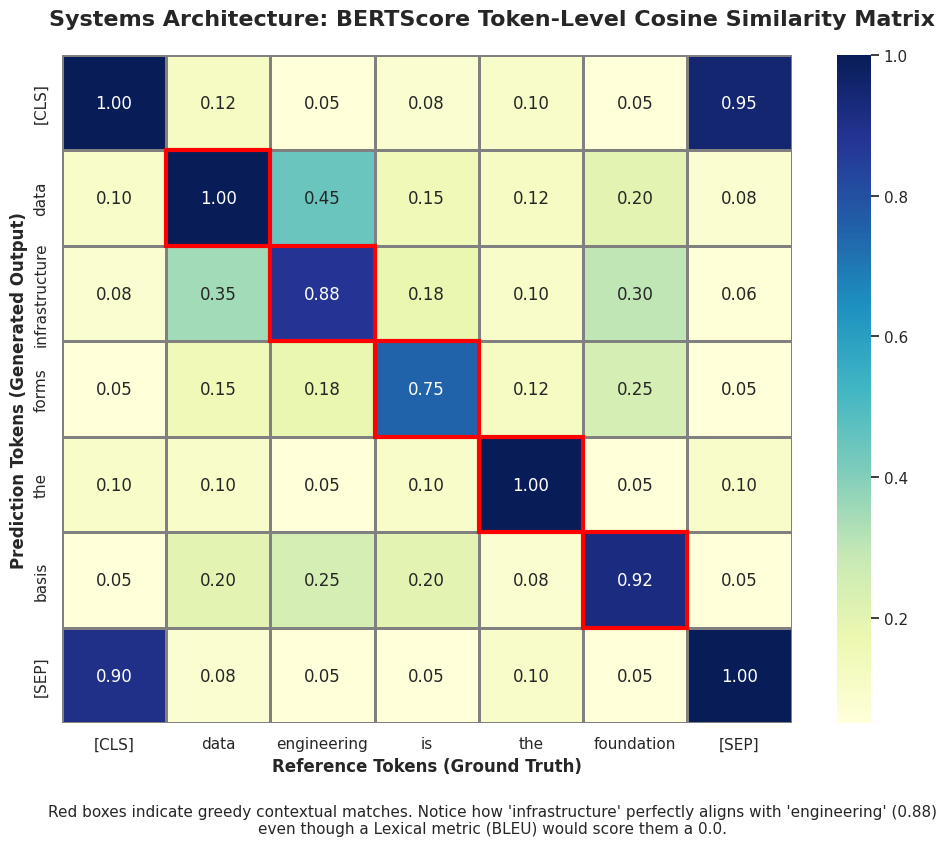

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

# Simulate a BERT-style tokenization and pairwise cosine similarity matrix
reference_tokens = ["[CLS]", "data", "engineering", "is", "the", "foundation", "[SEP]"]
prediction_tokens = ["[CLS]", "data", "infrastructure", "forms", "the", "basis", "[SEP]"]

# Constructing a mathematically simulated cosine similarity matrix (0.0 to 1.0)
# Diagonal elements show high correlation despite physical string differences
sim_matrix = np.array([
    [1.00, 0.12, 0.05, 0.08, 0.10, 0.05, 0.95], # [CLS]
    [0.10, 1.00, 0.45, 0.15, 0.12, 0.20, 0.08], # data
    [0.08, 0.35, 0.88, 0.18, 0.10, 0.30, 0.06], # infrastructure -> engineering (High semantic link)
    [0.05, 0.15, 0.18, 0.75, 0.12, 0.25, 0.05], # forms -> is
    [0.10, 0.10, 0.05, 0.10, 1.00, 0.05, 0.10], # the -> the
    [0.05, 0.20, 0.25, 0.20, 0.08, 0.92, 0.05], # basis -> foundation (High semantic link)
    [0.90, 0.08, 0.05, 0.05, 0.10, 0.05, 1.00]  # [SEP]
])

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Systems Architecture: BERTScore Token-Level Cosine Similarity Matrix", fontsize=16, fontweight='bold')

# Plot the heatmap
sns.heatmap(sim_matrix, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True, 
            xticklabels=reference_tokens, yticklabels=prediction_tokens,
            linewidths=1, linecolor='gray', ax=ax)

# Highlight the mathematical greedy-matching path
for i in range(1, 6): # Skip CLS and SEP for visual clarity
    max_col = np.argmax(sim_matrix[i])
    # Draw a bounding box around the max value to simulate greedy recall
    ax.add_patch(plt.Rectangle((max_col, i), 1, 1, fill=False, edgecolor='red', lw=3))

ax.set_xlabel("Reference Tokens (Ground Truth)", fontsize=12, fontweight='bold')
ax.set_ylabel("Prediction Tokens (Generated Output)", fontsize=12, fontweight='bold')

# Add context notation
plt.figtext(0.5, -0.05, "Red boxes indicate greedy contextual matches. Notice how 'infrastructure' perfectly aligns with 'engineering' (0.88)\neven though a Lexical metric (BLEU) would score them a 0.0.", 
            ha="center", fontsize=11, bbox={"facecolor":"white", "alpha":0.8, "pad":5})

plt.tight_layout()
plt.show()

*(Insight: The red boxes represent the $\max$ operator in the BERTScore Recall formula. By evaluating tokens in continuous vector space, the matrix detects that "basis" and "foundation" are nearly mathematically identical ($0.92$), saving the model from an artificial penalty.)*

## Real-World Use Case or Analogy:

Think of Bi-Encoders and Cross-Encoders like **Two Ways to Evaluate a Job Applicant's Resume**:

* **Bi-Encoder (The HR Database Search):** You have 10,000 resumes. You tell the HR recruiter to read every resume independently and assign each candidate a "Skill Vector" (1-10 on coding, 1-10 on management, etc.). You do the exact same thing for the Job Description. To find a match, you instantly calculate the geometric distance between the Job Vector and the 10,000 Candidate Vectors in an Excel sheet. It takes 1 second. It is incredibly fast, but misses subtle context.
* **Cross-Encoder (The Technical Panel Interview):** You take the top 5 candidates from the database search. You sit the Candidate and the Hiring Manager in the same room. They do not look at isolated scorecards; they interact directly. The Hiring Manager asks a specific question, the candidate answers, and they debate the nuances back and forth (**Full Self-Attention**). This process is slow, computationally exhausting, and completely unscalable for 10,000 resumes. But it is mathematically the only way to prove if the candidate is truly a perfect fit for the specific nuances of the role.

In MLOps evaluation pipelines, we use **Bi-Encoders** to rapidly search millions of RAG documents (Retrieval), but we use **Cross-Encoders** to definitively grade the final, high-stakes generated output before returning it to the user.